In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.datasets import cifar10
from numba import cuda
import math

# =====================================================
# Load CIFAR-10 Dataset
# =====================================================

(x_train, y_train), (_, _) = cifar10.load_data()

num_samples = 5

images = np.ascontiguousarray(
    x_train[:num_samples].astype(np.uint8)
)



# CUDA Bilateral Filter Kernel


In [25]:

@cuda.jit
def bilateral_filter_kernel(input_img, output_img,
                            sigma_space,
                            sigma_color):

    x, y = cuda.grid(2)

    h = input_img.shape[0]
    w = input_img.shape[1]

    if x < h and y < w:

        center_r = float(input_img[x, y, 0])
        center_g = float(input_img[x, y, 1])
        center_b = float(input_img[x, y, 2])

        for c in range(3):

            weighted_sum = 0.0
            weight_sum = 0.0

            center_val = float(input_img[x, y, c])

            for dx in range(-1, 2):
                for dy in range(-1, 2):

                    nx = x + dx
                    ny = y + dy

                    if 0 <= nx < h and 0 <= ny < w:

                        neighbor_val = float(
                            input_img[nx, ny, c]
                        )

                        # Spatial Gaussian
                        spatial_dist = dx*dx + dy*dy

                        spatial_weight = math.exp(
                            -spatial_dist /
                            (2.0 * sigma_space * sigma_space)
                        )

                        # Color Gaussian
                        color_diff = (
                            neighbor_val - center_val
                        )

                        color_weight = math.exp(
                            -(color_diff * color_diff) /
                            (2.0 * sigma_color * sigma_color)
                        )

                        weight = (
                            spatial_weight *
                            color_weight
                        )

                        weighted_sum += (
                            weight *
                            neighbor_val
                        )

                        weight_sum += weight

            output_img[x, y, c] = (
                weighted_sum / weight_sum
            )



# GPU Function

In [26]:
def bilateral_cuda(image,
                   sigma_space=1.5,
                   sigma_color=25.0):

    image = np.ascontiguousarray(image)

    d_input = cuda.to_device(image)

    d_output = cuda.device_array(
        image.shape,
        dtype=np.float32
    )

    threads = (16, 16)

    blocks = (
        (image.shape[0] + threads[0] - 1)
        // threads[0],

        (image.shape[1] + threads[1] - 1)
        // threads[1]
    )

    bilateral_filter_kernel[
        blocks,
        threads
    ](
        d_input,
        d_output,
        sigma_space,
        sigma_color
    )

    cuda.synchronize()

    return np.clip(
        d_output.copy_to_host(),
        0,
        255
    ).astype(np.uint8)


# Apply Bilateral Filter

In [27]:

filtered_images = []

for img in images:

    filtered = bilateral_cuda(
        img,
        sigma_space=1.5,
        sigma_color=25
    )

    filtered_images.append(filtered)

filtered_images = np.array(filtered_images)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


# Visualization

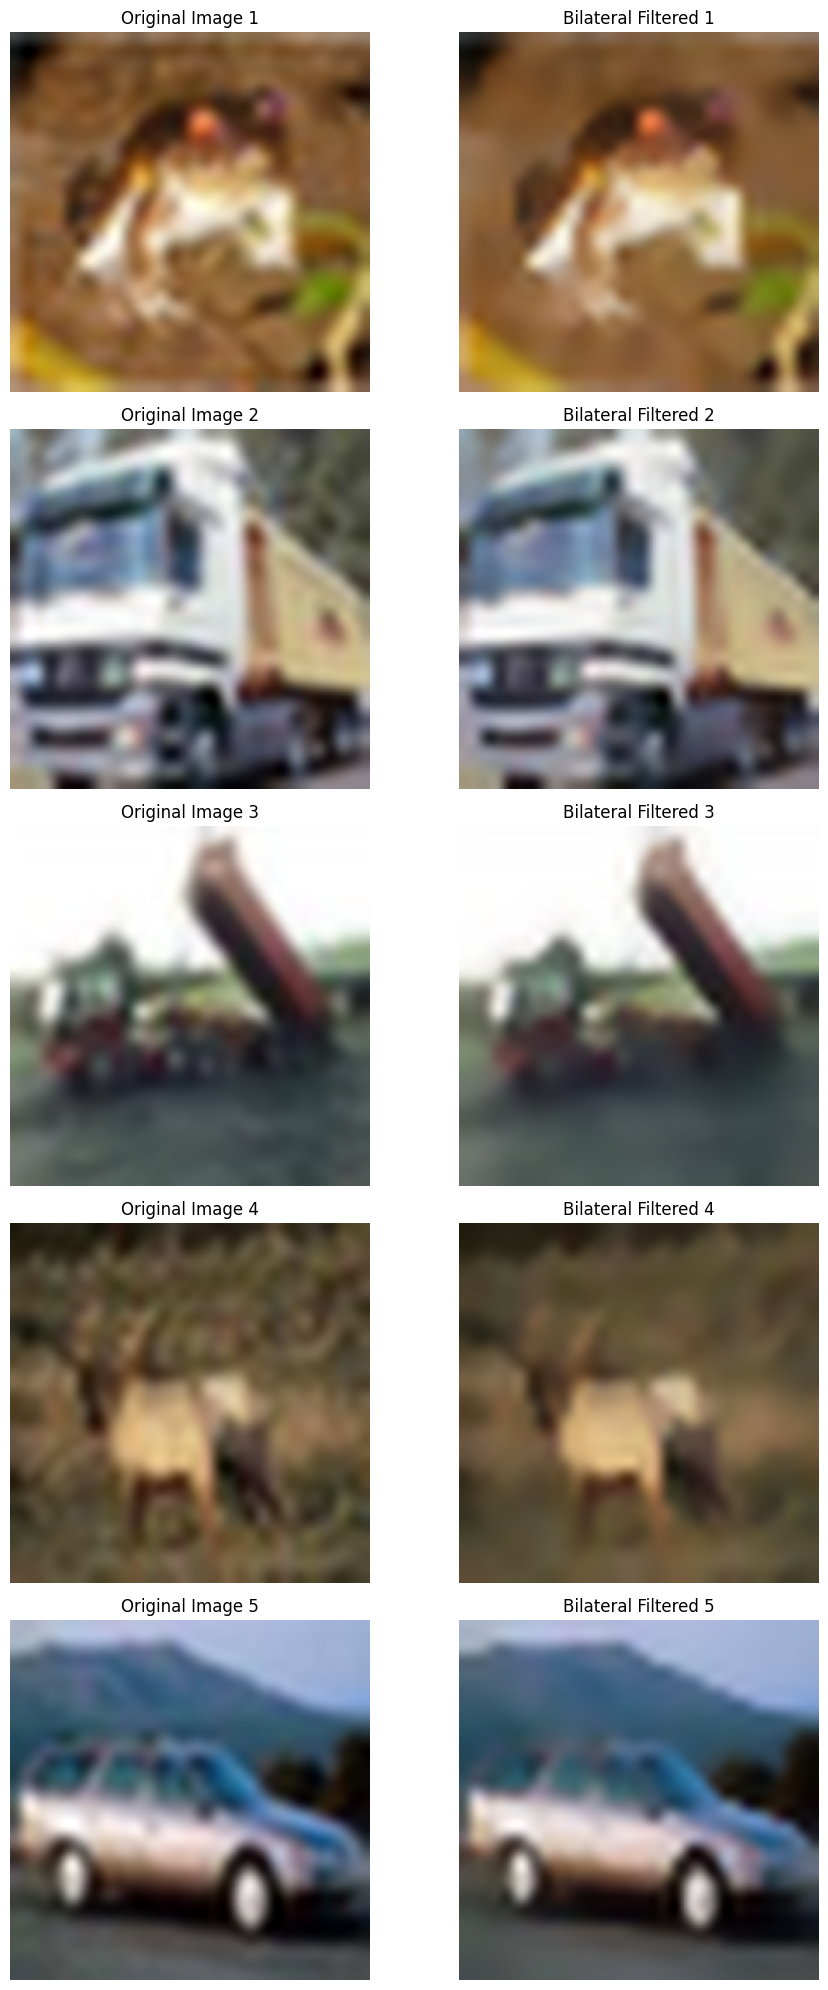

Dataset Shape : (50000, 32, 32, 3)
Image Shape   : (32, 32, 3)


In [28]:

UPSCALE = 256

fig, axes = plt.subplots(
    num_samples,
    2,
    figsize=(10, 4 * num_samples)
)

for i in range(num_samples):

    original = cv2.resize(
        images[i],
        (UPSCALE, UPSCALE),
        interpolation=cv2.INTER_LANCZOS4
    )

    filtered = cv2.resize(
        filtered_images[i],
        (UPSCALE, UPSCALE),
        interpolation=cv2.INTER_LANCZOS4
    )

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(
        f"Original Image {i+1}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(filtered)
    axes[i, 1].set_title(
        f"Bilateral Filtered {i+1}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

print("Dataset Shape :", x_train.shape)
print("Image Shape   :", x_train[0].shape)